# Import Libraries & Upload Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [ ]:
df = pd.read_csv("/content/hotel_bookings_updated_2024.csv")

# 1. Data Exploring

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow


In [ ]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
119385,City Hotel - Pune,0,23,2024,September,39,29,2,5,2,...,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2024-09-29 05:33:06.002060492,Pune
119386,City Hotel - Mumbai,0,102,2024,November,46,16,2,5,3,...,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2024-11-16 01:55:18.426320680,Mumbai
119387,City Hotel - Lucknow,0,34,2024,April,16,19,2,5,2,...,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2024-04-19 07:50:22.982016768,Lucknow
119388,City Hotel - Ahmedabad,0,109,2024,October,40,5,2,5,2,...,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2024-10-05 12:37:40.429352788,Ahmedabad
119389,City Hotel - Bhopal,0,205,2024,December,51,21,2,7,2,...,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2024-12-21 07:11:08.111802592,Bhopal


In [ ]:
df.sample(7)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
82015,City Hotel - Hyderabad,1,115,2024,October,43,26,2,0,1,...,41.0,NaN,22,Transient,70.00,0,0,Canceled,2024-10-26 13:21:53.457688732,Hyderabad
98862,City Hotel - Bangalore,0,25,2024,November,45,7,1,2,2,...,7.0,NaN,0,Transient,108.99,0,1,Check-Out,2024-11-07 21:43:14.862173232,Bangalore
41238,City Hotel - Hyderabad,0,39,2024,December,51,17,0,2,2,...,6.0,NaN,0,Transient-Party,109.00,0,0,Check-Out,2024-12-17 19:54:23.607199992,Hyderabad
98966,City Hotel - Ahmedabad,0,163,2024,April,16,18,2,3,2,...,168.0,NaN,0,Transient-Party,80.75,0,0,Check-Out,2024-04-18 08:39:13.181616396,Ahmedabad
53324,City Hotel - Mumbai,1,290,2024,August,31,2,1,2,2,...,3.0,NaN,108,Transient-Party,72.00,0,0,Canceled,2024-08-02 08:44:10.616053404,Mumbai
108749,City Hotel - Chennai,0,63,2024,December,52,27,0,4,2,...,9.0,NaN,0,Transient,101.78,0,0,Check-Out,2024-12-27 07:21:52.914925160,Chennai
46019,City Hotel - Kolkata,1,198,2024,November,45,9,2,1,2,...,1.0,NaN,0,Transient,90.00,0,0,Canceled,2024-11-09 02:46:36.257611672,Kolkata


In [ ]:
df.shape

(119390, 33)

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2024.0,26.375835,15.723394,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.0,15.021596,8.805079,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:

# Automatically detect and drop ALL columns that contain only zeros
df = df.loc[:, (df != 0).any(axis=0)]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


## Numerical Features

In [ ]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_features)

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')


## Categorical Features

In [ ]:
categorical_features = df.select_dtypes(include=["object", "category"]).columns

print(categorical_features)

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status',
       'reservation_status_date', 'city'],
      dtype='object')


# 2. Data Cleaning

## 1. Check Null Values

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


## Check Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates found.

## Handling Missing Values

In [ ]:
df["agent"] = df["agent"].fillna(0)
df["company"] = df["company"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["children"] = df["children"].fillna(0)

## Dropping Data Leakage Columns & Handling Outliers

In [ ]:
leakage_cols = ['reservation_status', 'reservation_status_date']

df = df.drop(
    columns=[col for col in leakage_cols if col in df.columns],
    errors="ignore"
)

# 3. Data Processing

## Feature Engineering

In [ ]:
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["total_stay_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]

## Remove Invalid Bookings (0 Guests)

In [ ]:
df = df[df["total_guests"] > 0]

## Creating Copies for EDA and Modeling

In [ ]:
cleaned_df = df.copy()
data = df.copy()
# Convert categorical columns to numbers
data = pd.get_dummies(
    data,
    columns=data.select_dtypes(include="object").columns,
    drop_first=True
)

# 4. Exploratory Data Analysis (EDA)

## 4.1. Target

1. This visualization helps us to know that: Non-canceled bookings represent about 62.9% of all bookings, while canceled bookings account for about 37.1%, showing that cancellation is a substantial part of the dataset.

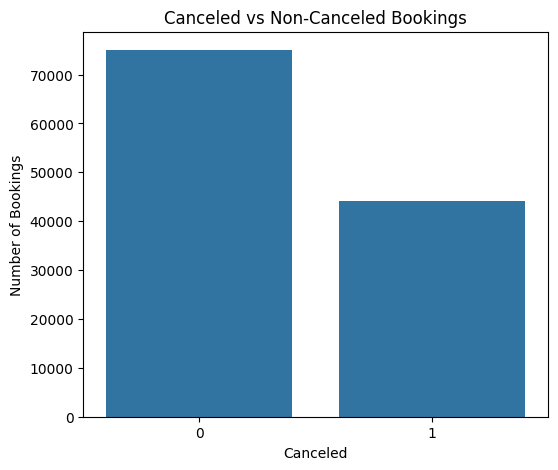

is_canceled
0    0.629234
1    0.370766
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="is_canceled")

plt.title("Canceled vs Non-Canceled Bookings")
plt.xlabel("Canceled")
plt.ylabel("Number of Bookings")

plt.show()

# Percentage of each class
print(df["is_canceled"].value_counts(normalize=True))

In [ ]:
df["is_canceled"].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,62.923412
1,37.076588


## 4.2. Visualizations between the most important features and the target

2. This visualization represents that booking volume varies slightly across cities, but every city shows a considerable number of cancellations alongside successful bookings.

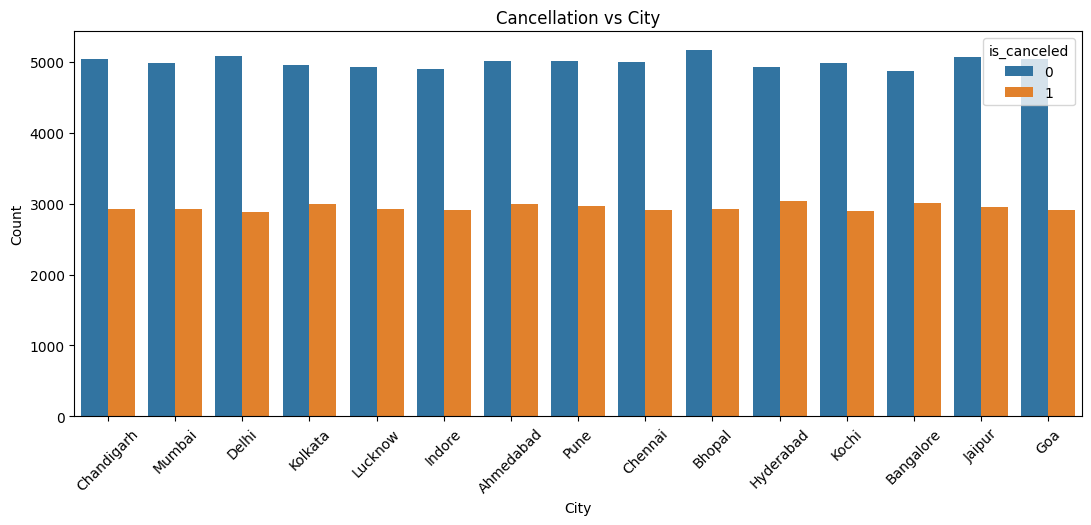

In [ ]:
plt.figure(figsize=(13, 5))

sns.countplot(data=df, x="city", hue="is_canceled")

plt.title("Cancellation vs City")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

3. This visualization shows us that cancellation behavior differs across customer types, showing that some customer groups are more likely to cancel than others even when their total booking volumes are smaller.

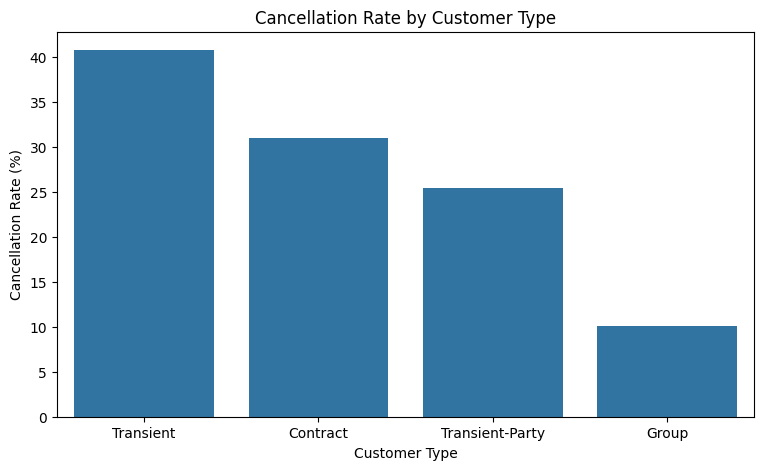

In [ ]:
customer_cancel = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index(name="cancellation_rate")
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=customer_cancel,
    x="customer_type",
    y="cancellation_rate"
)

plt.title("Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

4. This visualization shows us that City hotels have considerably more bookings and cancellations than Resort hotels, mainly because they receive a larger overall number of bookings.

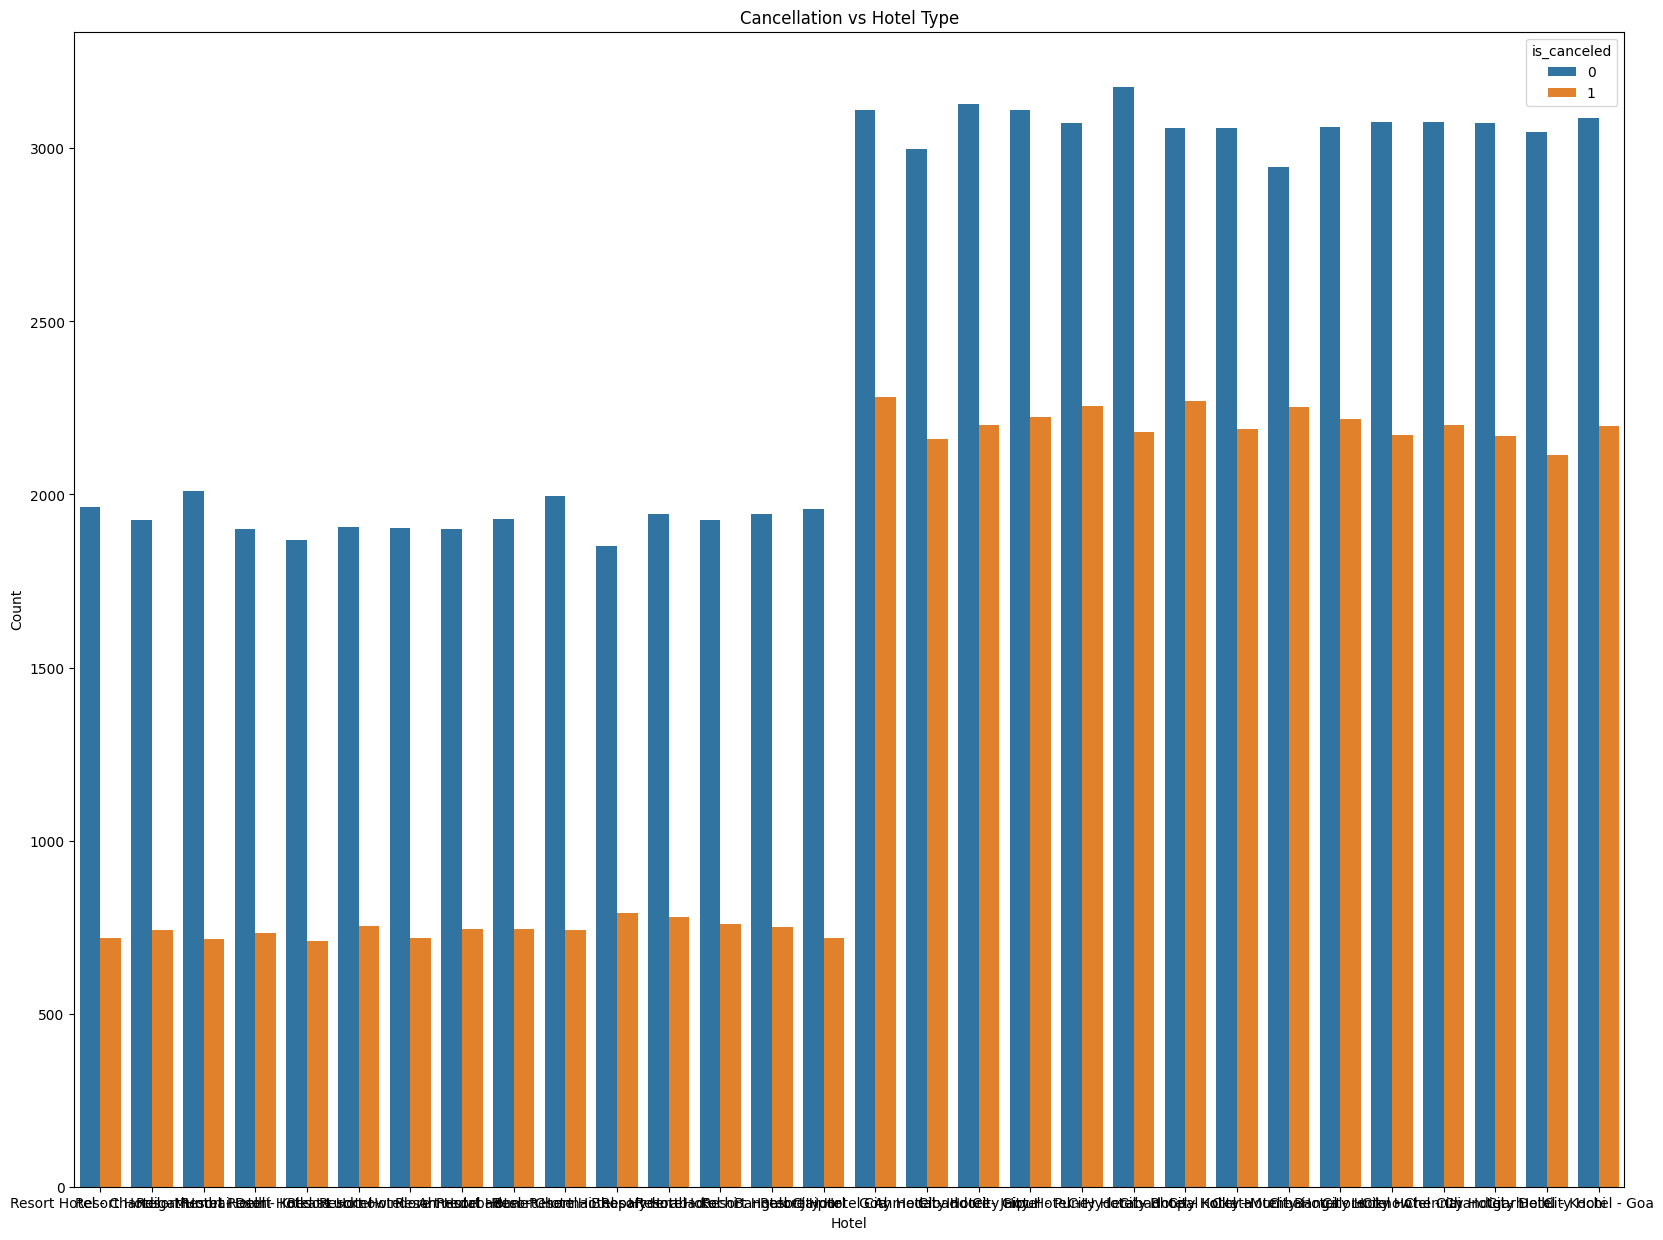

In [ ]:
plt.figure(figsize=(20,15))

sns.countplot(data=df, x="hotel", hue="is_canceled")

plt.title("Cancellation vs Hotel Type")
plt.xlabel("Hotel")
plt.ylabel("Count")

plt.show()

5. This visualization shows us that Transient customers dominate the dataset and contribute the largest number of both canceled and non-canceled bookings.

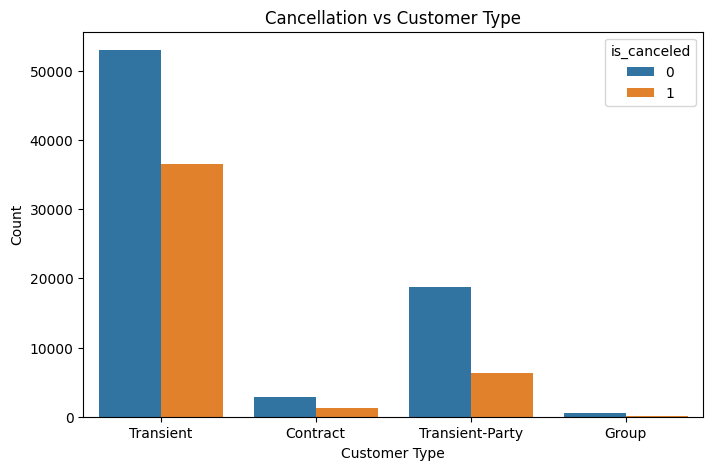

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="customer_type", hue="is_canceled")

plt.title("Cancellation vs Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.show()

6. This visualization shows us that cancellation rates vary considerably between market segments, indicating that the way a booking is acquired is associated with its likelihood of cancellation.

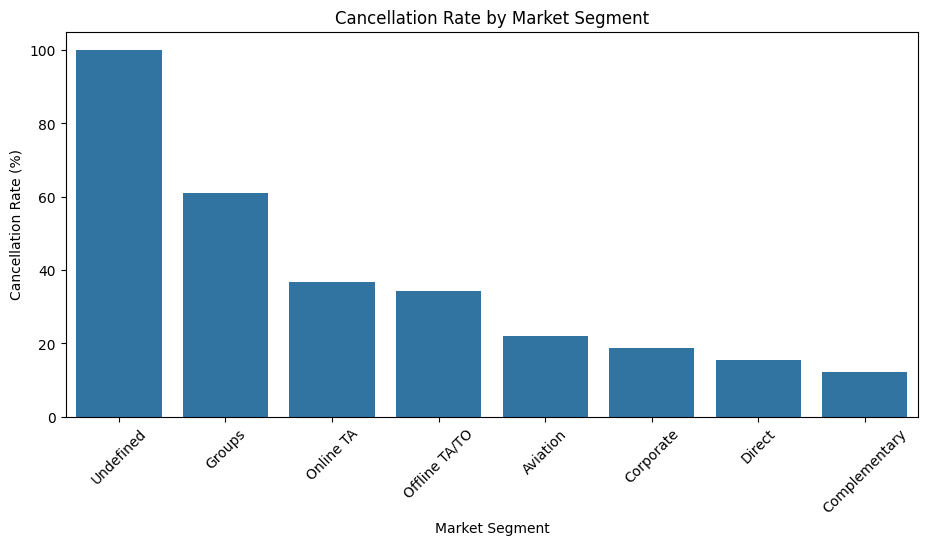

In [ ]:
market_cancel = (
    df.groupby("market_segment")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index(name="cancellation_rate")
)

plt.figure(figsize=(11, 5))

sns.barplot(
    data=market_cancel,
    x="market_segment",
    y="cancellation_rate"
)

plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)

plt.show()

7. This visualization shows us that deposit type shows a strong relationship with cancellation, with Non-Refund bookings having an exceptionally high cancellation rate compared with the other deposit categories.

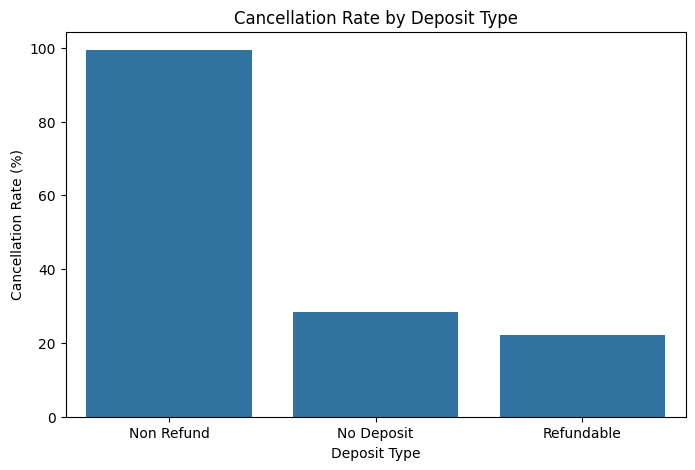

In [ ]:
deposit_cancel = (
    df.groupby("deposit_type")["is_canceled"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .reset_index(name="cancellation_rate")
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=deposit_cancel,
    x="deposit_type",
    y="cancellation_rate"
)

plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

8. This visualization shows us that repeated guests have a different cancellation rate from non-repeated guests, suggesting that previous hotel experience is associated with cancellation behavior.

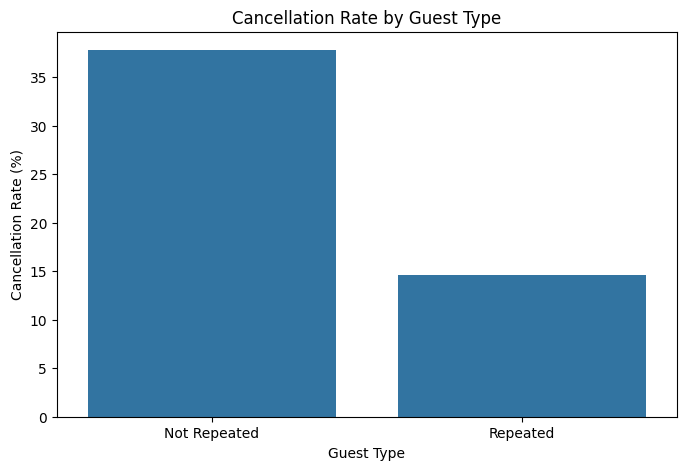

In [ ]:
repeated_cancel = (
    df.groupby("is_repeated_guest")["is_canceled"]
      .mean()
      .mul(100)
      .reset_index(name="cancellation_rate")
)

repeated_cancel["guest_type"] = repeated_cancel["is_repeated_guest"].map({
    0: "Not Repeated",
    1: "Repeated"
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=repeated_cancel,
    x="guest_type",
    y="cancellation_rate"
)

plt.title("Cancellation Rate by Guest Type")
plt.xlabel("Guest Type")
plt.ylabel("Cancellation Rate (%)")

plt.show()

9. The given boxplot shows us that the distribution of stay length is broadly similar for canceled and non-canceled bookings, with most stays being short and several long-stay outliers.

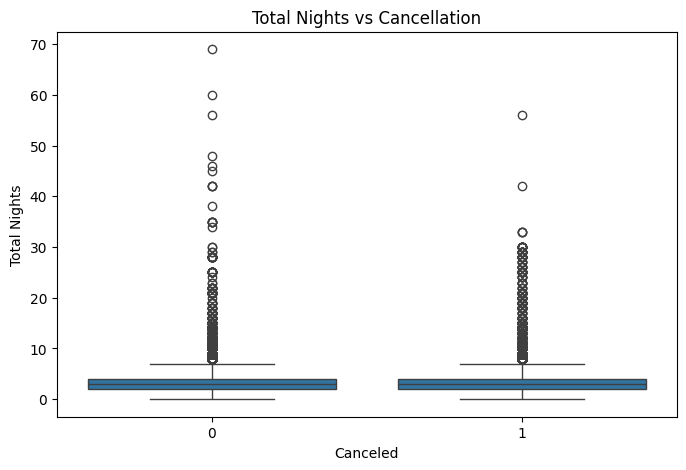

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_canceled", y="total_stay_nights")

plt.title("Total Nights vs Cancellation")
plt.xlabel("Canceled")
plt.ylabel("Total Nights")

plt.show()

10. We could understand from the given visualization that the central ADR distributions of canceled and non-canceled bookings are relatively similar, suggesting that ADR alone does not strongly distinguish between the two groups.

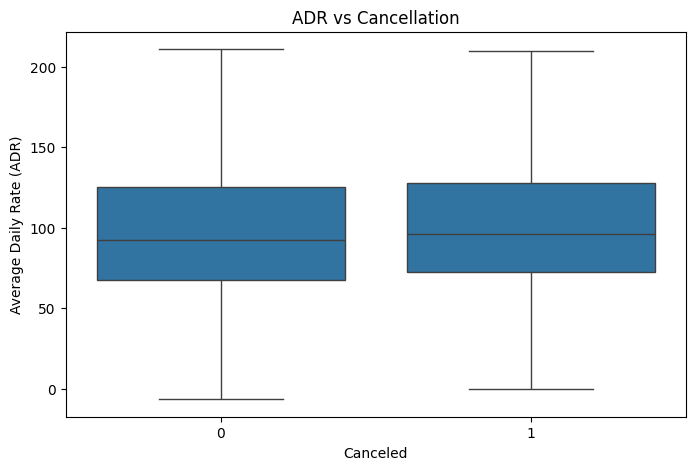

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="adr",
    showfliers=False
)

plt.title("ADR vs Cancellation")
plt.xlabel("Canceled")
plt.ylabel("Average Daily Rate (ADR)")

plt.show()

11. The given boxplot shows us that lead time is strongly right-skewed, meaning most bookings are made relatively close to arrival while only a small number are made many months in advance.

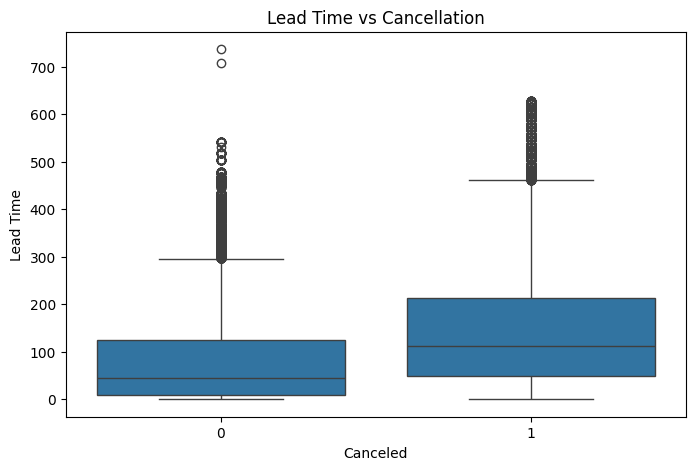

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_canceled", y="lead_time")

plt.title("Lead Time vs Cancellation")
plt.xlabel("Canceled")
plt.ylabel("Lead Time")

plt.show()

12. The given boxplot shows us that TA/TO is the dominant distribution channel and also produces the largest number of cancellations, while Direct and Corporate channels have much lower volumes.

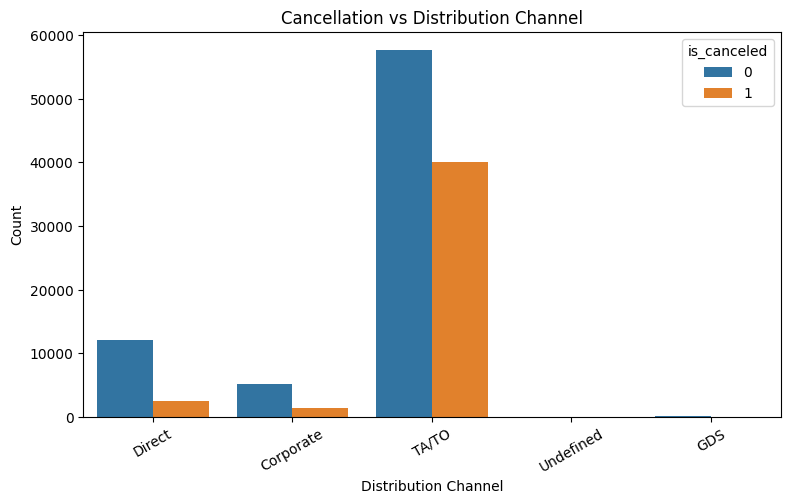

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x="distribution_channel", hue="is_canceled")

plt.title("Cancellation vs Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.show()

## 4.3. Visualizations For the most important features in our dataset

13. This visualization shows us that the lead time is strongly right-skewed, with most bookings made relatively close to arrival and progressively fewer bookings made far in advance.

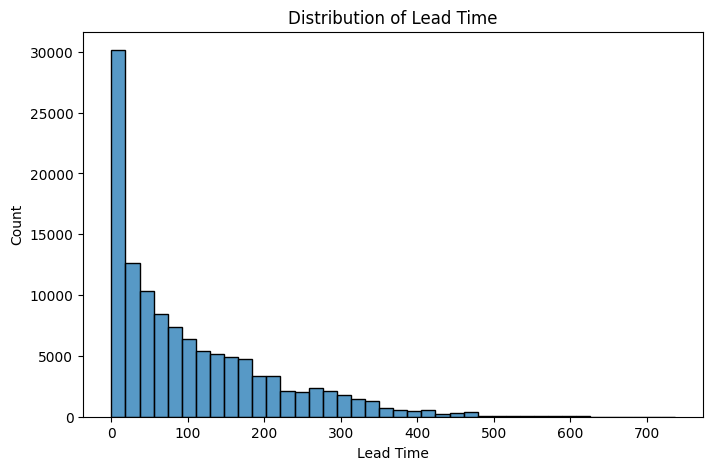

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="lead_time", bins=40)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time")
plt.ylabel("Count")

plt.show()

14. This visualization represents to us that ADR is highly right-skewed, with most bookings concentrated at relatively low daily rates and a small number of extreme high-rate observations.

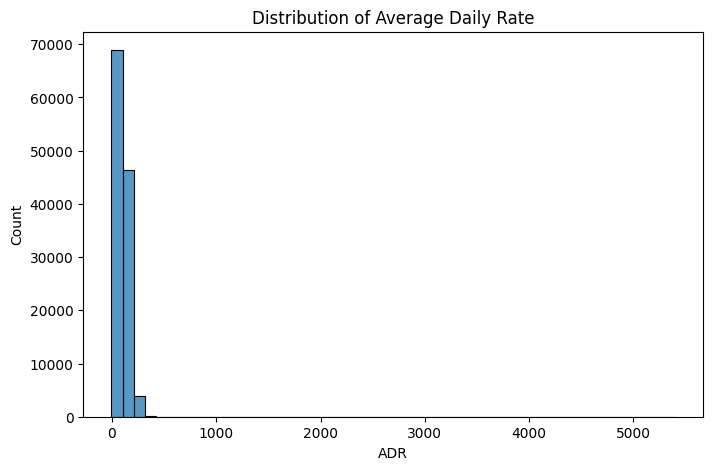

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="adr", bins=50)

plt.title("Distribution of Average Daily Rate")
plt.xlabel("ADR")
plt.ylabel("Count")

plt.show()

## Using Log to Prevent Right Skewed

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


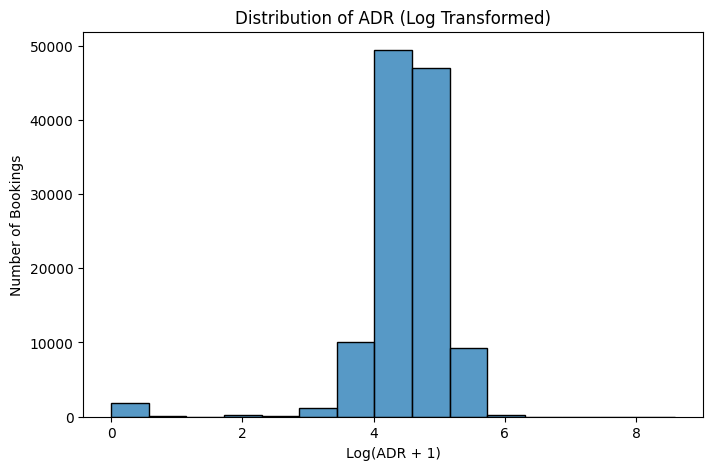

In [ ]:
df["log_adr"] = np.log1p(df["adr"])

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="log_adr",
    bins=15
)

plt.title("Distribution of ADR (Log Transformed)")
plt.xlabel("Log(ADR + 1)")
plt.ylabel("Number of Bookings")

plt.show()

15. This visualization represents that most bookings involve short stays of only a few nights, while longer stays occur much less frequently and create a long right tail.

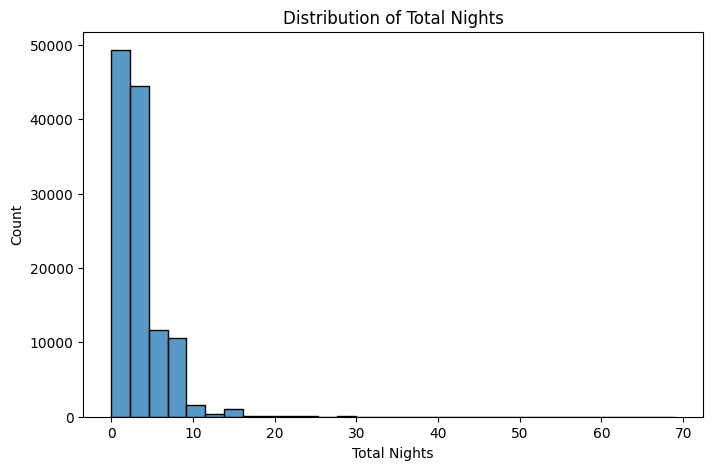

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="total_stay_nights", bins=30)

plt.title("Distribution of Total Nights")
plt.xlabel("Total Nights")
plt.ylabel("Count")

plt.show()

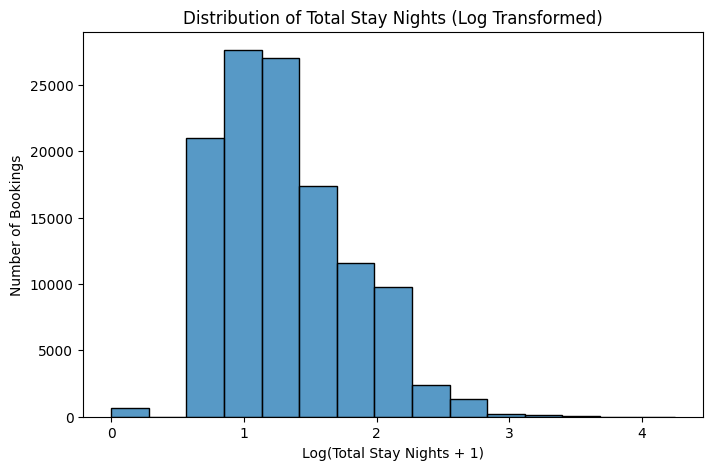

In [ ]:
df["log_total_stay_nights"] = np.log1p(df["total_stay_nights"])

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="log_total_stay_nights",
    bins=15
)

plt.title("Distribution of Total Stay Nights (Log Transformed)")
plt.xlabel("Log(Total Stay Nights + 1)")
plt.ylabel("Number of Bookings")

plt.show()

16. This visualization represents to us that bookings are mainly for two guests, while reservations involving larger numbers of guests become increasingly rare.

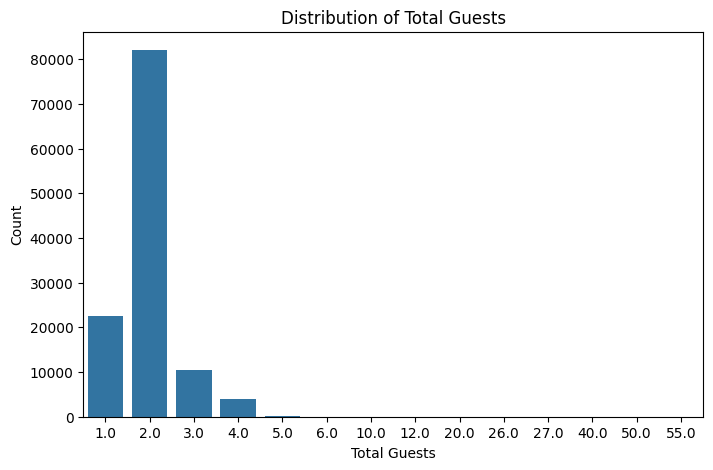

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="total_guests")

plt.title("Distribution of Total Guests")
plt.xlabel("Total Guests")
plt.ylabel("Count")

plt.show()

17. This graph shows us the relation between the lead time and the ADR (Avg. Daily Rate) and it makes us know that there is no strong linear relationship between lead time and ADR, as bookings with different lead times generally span a similar range of daily rates.

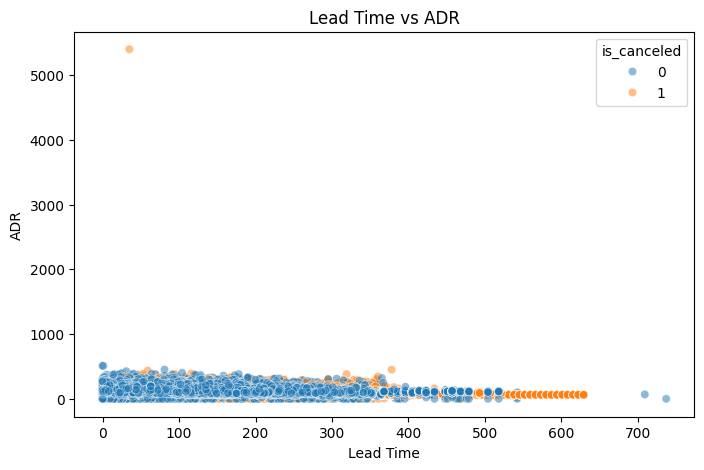

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="is_canceled",
    alpha=0.5
)

plt.title("Lead Time vs ADR")
plt.xlabel("Lead Time")
plt.ylabel("ADR")

plt.show()

18. This visualization makes us know that ADR and total stay nights show no strong relationship, with most bookings concentrated around short stays and moderate ADR values.

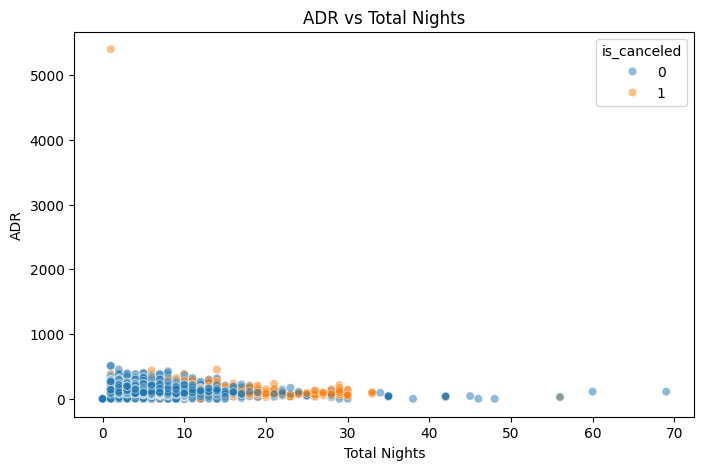

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_stay_nights",
    y="adr",
    hue="is_canceled",
    alpha=0.5
)

plt.title("ADR vs Total Nights")
plt.xlabel("Total Nights")
plt.ylabel("ADR")

plt.show()

19. The correlation heatmap shows the strength and direction of relationships between numerical variables and helps identify features that may have useful associations with booking cancellation.

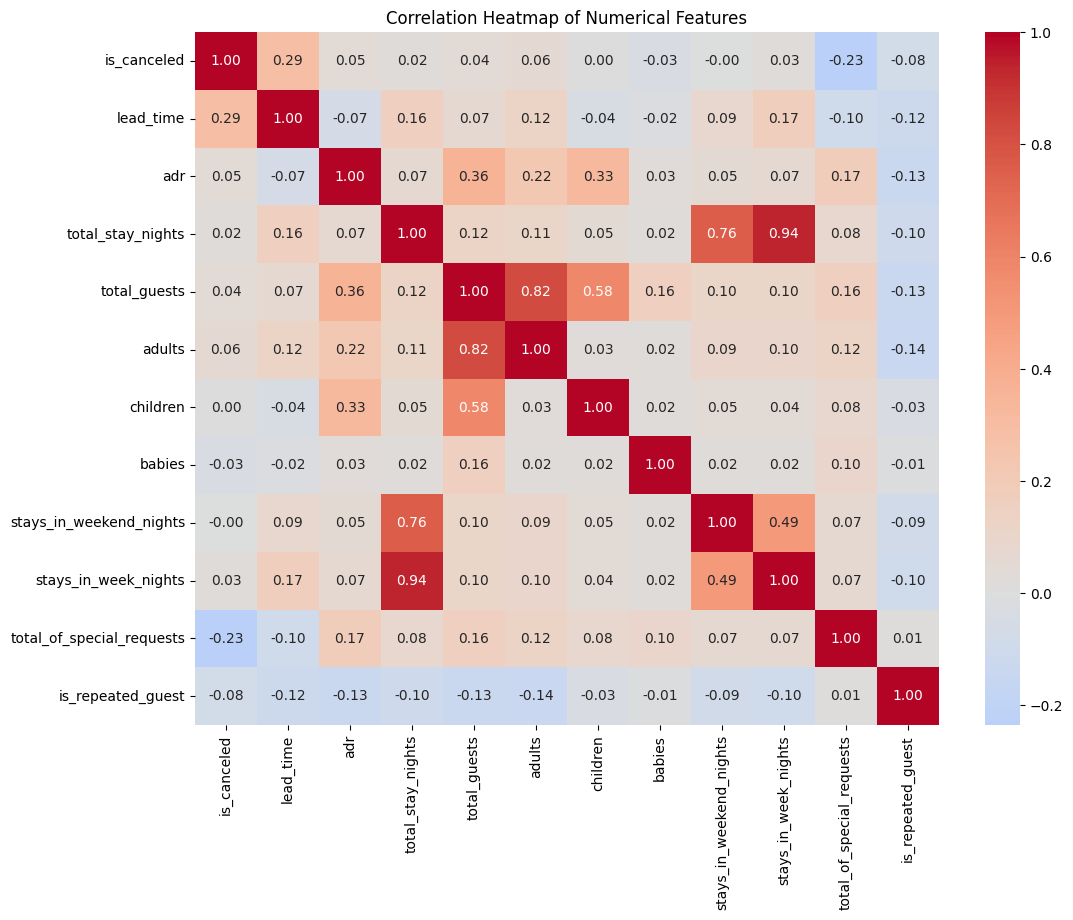

In [ ]:
numeric_cols = [
    "is_canceled",
    "lead_time",
    "adr",
    "total_stay_nights",
    "total_guests",
    "adults",
    "children",
    "babies",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "total_of_special_requests",
    "is_repeated_guest"
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

# Classification Model

In the Hotel Booking dataset:
Predict whether a hotel booking will be canceled or not canceled using `is_canceled`.

In [ ]:
X = data.drop("is_canceled", axis=1)
y = data["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1. Logistic Regression

In [ ]:
logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic.fit(X_train_scaled, y_train)

y_pred_lr = logistic.predict(X_test_scaled)
y_prob_lr = logistic.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8137320694572603
Precision: 0.8043448180434482
Recall: 0.657579185520362
F1 Score: 0.7235949461629427


## 2. Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [ ]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.8319352403321869
Precision: 0.7699698357725394
Recall: 0.7796380090497738
F1 Score: 0.7747737620145018


## 3. Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8707742639040349
Precision: 0.8777384231929687
Recall: 0.7569004524886878
F1 Score: 0.812853064447549


## 4. KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

KNN
Accuracy: 0.7478818891032631
Precision: 0.6666274001649193
Recall: 0.6401583710407239
F1 Score: 0.6531248196664551


## 5. Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [ ]:
print("Gradient Boosting")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

Gradient Boosting
Accuracy: 0.845398875933227
Precision: 0.8266987829614605
Recall: 0.7376696832579186
F1 Score: 0.7796508847441416


## 6. XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [ ]:
print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))

XGBoost
Accuracy: 0.8711517490143444
Precision: 0.85
Recall: 0.7923076923076923
F1 Score: 0.8201405152224824


<Figure size 1000x600 with 0 Axes>

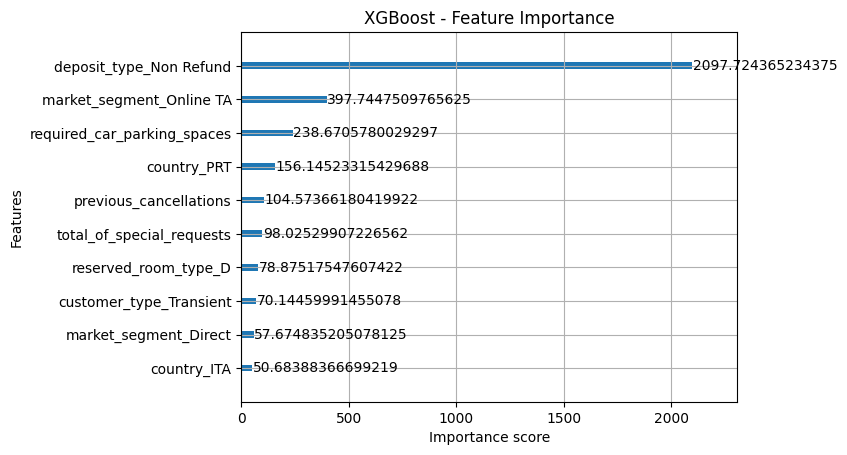

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plot_importance(
    xgb,
    importance_type="gain",
    max_num_features=10
)

plt.title("XGBoost - Feature Importance")
plt.show()

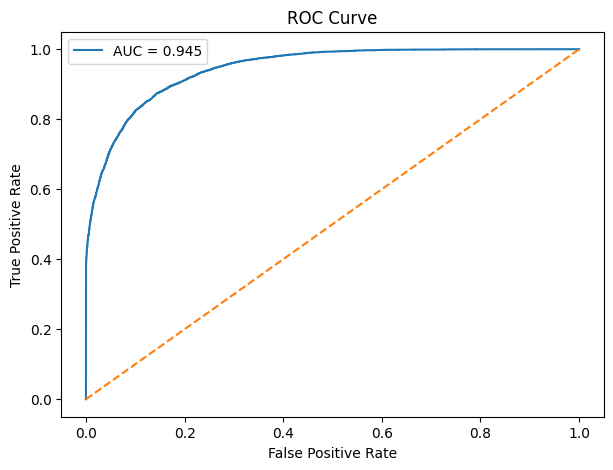

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability of positive class
y_prob = xgb.predict_proba(X_test)[:, 1]

# Calculate ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 7. Comparison

In [ ]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb)
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.813732,0.804345,0.657579,0.723595
1,Decision Tree,0.831935,0.769970,0.779638,0.774774
2,Random Forest,0.870774,0.877738,0.756900,0.812853
3,KNN,0.747882,0.666627,0.640158,0.653125
4,Gradient Boosting,0.845399,0.826699,0.737670,0.779651
5,XGBoost,0.871152,0.850000,0.792308,0.820141


# Regression Model

In the Hotel Booking dataset:
It can be used to predict a numerical value such as the Average Daily Rate (`adr`) based on the booking information.

In [ ]:
X_reg = data.drop("adr", axis=1)
y_reg = data["adr"]

# Remove negative ADR values
valid = y_reg >= 0

X_reg = X_reg[valid]
y_reg = y_reg[valid]

In [ ]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)
reg_scaler = StandardScaler()

X_train_reg_scaled = reg_scaler.fit_transform(X_train_reg)
X_test_reg_scaled = reg_scaler.transform(X_test_reg)

## 1. Linear Regression

In [ ]:
linear = LinearRegression()

linear.fit(
    X_train_reg_scaled,
    y_train_reg
)

pred_linear = linear.predict(X_test_reg_scaled)

In [ ]:
print("Linear Regression")

print("MAE:",
      mean_absolute_error(y_test_reg, pred_linear))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, pred_linear)))

print("R2:",
      r2_score(y_test_reg, pred_linear))

Linear Regression
MAE: 26.28309601392146
RMSE: 49.663707119515045
R2: 0.29013085673983574


## 2. Decision Tree Regression

In [ ]:
dt_reg = DecisionTreeRegressor(
    random_state=42
)

dt_reg.fit(
    X_train_reg,
    y_train_reg
)

pred_dt_reg = dt_reg.predict(X_test_reg)

In [ ]:
print("Decision Tree Regression")

print("MAE:",
      mean_absolute_error(y_test_reg, pred_dt_reg))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, pred_dt_reg)))

print("R2:",
      r2_score(y_test_reg, pred_dt_reg))

Decision Tree Regression
MAE: 23.52568576461706
RMSE: 53.108601416665
R2: 0.18823605162411527


## 3. Random Forest Regression

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(
    X_train_reg,
    y_train_reg
)

pred_rf_reg = rf_reg.predict(X_test_reg)

In [ ]:
print("Random Forest Regression")

print("MAE:",
      mean_absolute_error(y_test_reg, pred_rf_reg))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, pred_rf_reg)))

print("R2:",
      r2_score(y_test_reg, pred_rf_reg))

Random Forest Regression
MAE: 18.343583455966062
RMSE: 45.109491460643746
R2: 0.4143530408416848


## 4. Gradient Boosting Regression

In [ ]:
gb_reg = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb_reg.fit(
    X_train_reg,
    y_train_reg
)

pred_gb_reg = gb_reg.predict(X_test_reg)

In [ ]:
print("Gradient Boosting Regression")

print("MAE:",
      mean_absolute_error(y_test_reg, pred_gb_reg))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test_reg, pred_gb_reg)))

print("R2:",
      r2_score(y_test_reg, pred_gb_reg))

Gradient Boosting Regression
MAE: 25.872110828122974
RMSE: 48.89593383241668
R2: 0.31190956618245913


## Comparison

In [ ]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mean_absolute_error(y_test_reg, pred_linear),
        mean_absolute_error(y_test_reg, pred_dt_reg),
        mean_absolute_error(y_test_reg, pred_rf_reg),
        mean_absolute_error(y_test_reg, pred_gb_reg)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, pred_linear)),
        np.sqrt(mean_squared_error(y_test_reg, pred_dt_reg)),
        np.sqrt(mean_squared_error(y_test_reg, pred_rf_reg)),
        np.sqrt(mean_squared_error(y_test_reg, pred_gb_reg))
    ],

    "R2": [
        r2_score(y_test_reg, pred_linear),
        r2_score(y_test_reg, pred_dt_reg),
        r2_score(y_test_reg, pred_rf_reg),
        r2_score(y_test_reg, pred_gb_reg)
    ]
})

regression_results

,Model,MAE,RMSE,R2
0,Linear Regression,26.283096,49.663707,0.290131
1,Decision Tree,23.525686,53.108601,0.188236
2,Random Forest,18.343583,45.109491,0.414353
3,Gradient Boosting,25.872111,48.895934,0.311910


# Clustering Model

In the Hotel Booking dataset:
It can be used to discover different groups of bookings/customers based on characteristics such as lead time, stay length, ADR, number of guests, and other features.

### 1. Preparing Data for Clustering

In [ ]:
cluster_features = [
    "lead_time",
    "adr",
]

cluster_data = df[cluster_features].copy()

In [ ]:
cluster_data.head()

,lead_time,adr
0,342,0.0
1,737,0.0
2,7,75.0
3,13,75.0
4,14,98.0


### 2. Feature Scaling

In [ ]:
cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(cluster_data)

X_cluster[:5]

array([[ 2.22587854, -2.02184054],
       [ 5.92178491, -2.02184054],
       [-0.90862434, -0.53474246],
       [-0.85248399, -0.53474246],
       [-0.84312726, -0.07869905]])

### 3. Elbow Method

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

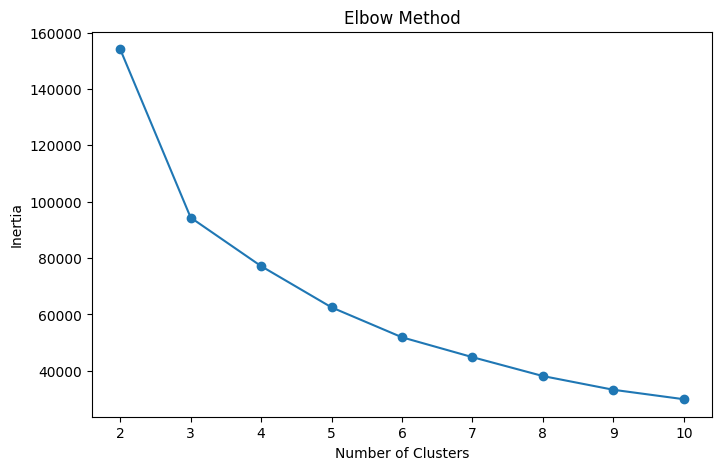

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

### 4. Silhouette Score

In [ ]:
silhouette_scores = []

sample_size = 10000

X_sample = X_cluster[
    np.random.RandomState(42).choice(
        X_cluster.shape[0],
        sample_size,
        replace=False
    )
]

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)
    silhouette_scores.append(score)

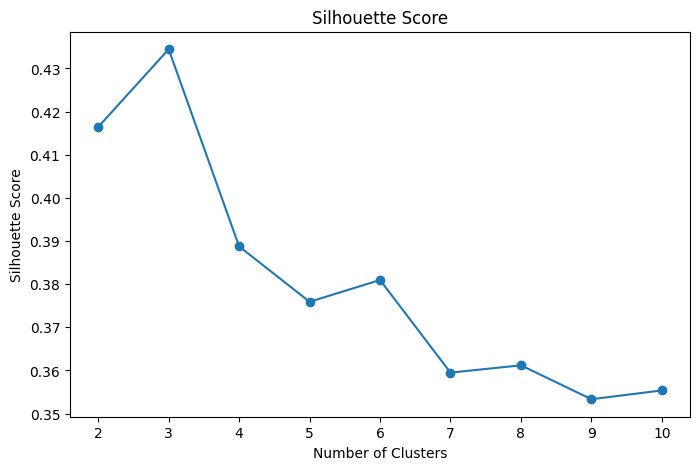

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

### 5. K-Means Clustering

## Selecting the Best Number of Clusters

In [ ]:
best_k = range(2, 11)[
    np.argmax(silhouette_scores)
]

best_k

3

In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster)

cluster_data["cluster"] = cluster_labels

cluster_data.head()

,lead_time,adr,cluster
0,342,0.0,1
1,737,0.0,1
2,7,75.0,0
3,13,75.0,0
4,14,98.0,0


### 6. Clustering Evaluation

In [ ]:
final_silhouette = silhouette_score(
    X_cluster,
    cluster_labels
)

print("Number of Clusters:", best_k)
print("Silhouette Score:", round(final_silhouette, 4))

Number of Clusters: 3
Silhouette Score: 0.4365


### 7. Cluster Analysis

In [ ]:
cluster_summary = cluster_data.groupby("cluster").mean()

cluster_summary

,lead_time,adr
cluster,,
0,48.769023,77.358722
1,262.282777,88.638023
2,69.706499,165.025090


In [ ]:
cluster_counts = cluster_data["cluster"].value_counts().sort_index()

cluster_counts

,count
cluster,
0,61374
1,27969
2,29867


### 8. Cluster Visualization

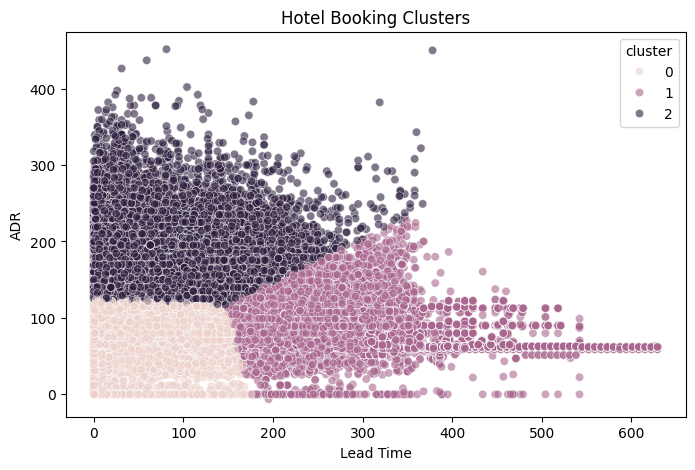

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=cluster_data[
        (cluster_data["adr"] < 500) &
        (cluster_data["lead_time"] < 700)
    ],
    x="lead_time",
    y="adr",
    hue="cluster",
    alpha=0.6
)

plt.title("Hotel Booking Clusters")
plt.xlabel("Lead Time")
plt.ylabel("ADR")

plt.show()

### 9. Clustering Conclusion

The K-Means clustering model divided the hotel bookings into 3 clusters based on lead time, total stay nights, ADR, total guests, and special requests.

The optimal number of clusters was selected using the Silhouette Score, where 3 clusters achieved the highest score.

The clustering results show that hotel bookings can be grouped into different segments based on booking behavior and stay characteristics.

# Fine Tuning

## Fine Tuning XGBoost
XGBoost was selected for fine tuning because it achieved the highest F1 Score among the classification models.

In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

xgb_tuned = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

xgb_tuned.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [ ]:
print("Best Parameters:", xgb_tuned.best_params_)
print("Best F1 Score:", round(xgb_tuned.best_score_, 4))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best F1 Score: 0.8071


In [ ]:
y_pred_tuned = xgb_tuned.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Accuracy:", round(tuned_accuracy, 4)*100,"%")
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1 Score:", round(tuned_f1, 4))

Accuracy: 86.41 %
Precision: 0.846
Recall: 0.7744
F1 Score: 0.8086
